# EDA — Кредитный скоринг (прогноз дефолта)

Разведочный анализ данных для задачи Альфа-Банк × МФТИ.

**Финальный результат: OOF ROC-AUC = 0.78340 → public LB = 0.7835.**

Содержание:
1. Обзор данных (long-формат, размеры, типы)
2. Целевая переменная и дисбаланс
3. Длина последовательностей (продуктов на клиента)
4. Признаки — категориальные коды и их кардинальности
5. Одномерная предсказательная сила (id-level)
6. Категориальные признаки vs target
7. Sentinel-коды и распределения
8. Временная структура и train/test
9. Корреляционная матрица id-агрегатов
10. Выводы

> ⚠️ Ноутбук грузит сырой long-файл (~1 ГБ → ~3 ГБ в памяти). Нужно ≥6 ГБ свободной RAM.

In [11]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

REPO = Path(".").resolve().parent
sys.path.insert(0, str(REPO / "src"))
from credit_scoring import config as C   # column groups: ENC_PAYM_COLS, DELINQ_COLS, ...

ID, RN, TGT = C.ID_COL, C.RN_COL, C.TARGET_COL

## 1. Обзор данных (long-формат)

In [12]:
# Сырой long: одна строка = один кредитный продукт; клиент = много строк (по rn)
train = pd.read_parquet(REPO / "data/raw/train_data.parquet")
test  = pd.read_parquet(REPO / "data/raw/test_data.parquet")
target = pd.read_csv(REPO / "data/raw/train_target.csv").set_index(ID)[TGT]

feature_cols = [c for c in train.columns if c not in (ID, RN)]
print(f"Train: {len(train):,} строк × {train.shape[1]} колонок | {train[ID].nunique():,} клиентов")
print(f"Test:  {len(test):,} строк × {test.shape[1]} колонок | {test[ID].nunique():,} клиентов")
print(f"Признаков на продукт: {len(feature_cols)}")
print(f"\nТипы колонок:\n{train.dtypes.value_counts()}")
print(f"\nПропуски (train): {int(train.isnull().sum().sum())} | (test): {int(test.isnull().sum().sum())}")
train.head()

Train: 18,317,016 строк × 61 колонок | 2,100,000 клиентов
Test:  7,845,701 строк × 61 колонок | 900,000 клиентов
Признаков на продукт: 59

Типы колонок:
int64    61
Name: count, dtype: int64

Пропуски (train): 0 | (test): 0


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,2250000,1,4,2,9,12,5,7,6,2,...,3,3,3,4,1,3,5,1,0,0
1,2250000,2,3,17,15,9,15,14,1,2,...,3,3,3,4,1,3,4,1,0,0
2,2250000,3,3,3,16,9,15,14,10,2,...,3,3,3,4,1,3,4,1,0,0
3,2250000,4,11,17,14,7,14,8,9,2,...,3,3,3,4,1,3,4,1,0,0
4,2250000,5,11,6,4,8,1,11,14,2,...,3,3,3,4,1,2,3,1,1,1


## 2. Целевая переменная и дисбаланс\n\nМетка `flag` — одна на клиента (`id`): 1 = дефолт, 0 = выплатил.

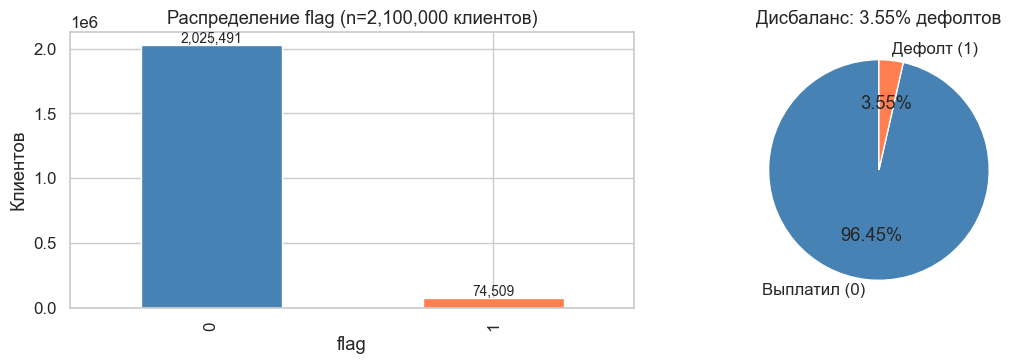

Prevalence: 0.0355 (74,509 из 2,100,000) → scale_pos_weight ≈ 27.2


In [13]:
y = target.reindex(np.sort(train[ID].unique()))
prevalence = y.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y.value_counts().sort_index().plot.bar(ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title(f"Распределение flag (n={len(y):,} клиентов)")
axes[0].set_xlabel("flag"); axes[0].set_ylabel("Клиентов")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=10)
axes[1].pie([1-prevalence, prevalence], labels=["Выплатил (0)", "Дефолт (1)"],
            autopct="%1.2f%%", colors=["steelblue", "coral"], startangle=90)
axes[1].set_title(f"Дисбаланс: {prevalence:.2%} дефолтов")
plt.tight_layout(); plt.show()
print(f"Prevalence: {prevalence:.4f} ({int(y.sum()):,} из {len(y):,}) → scale_pos_weight ≈ {(1-prevalence)/prevalence:.1f}")

## 3. Длина последовательностей

Сколько кредитных продуктов в истории клиента. Это мотивирует параметр `max_len` seq-модели (усекаем до N последних продуктов).

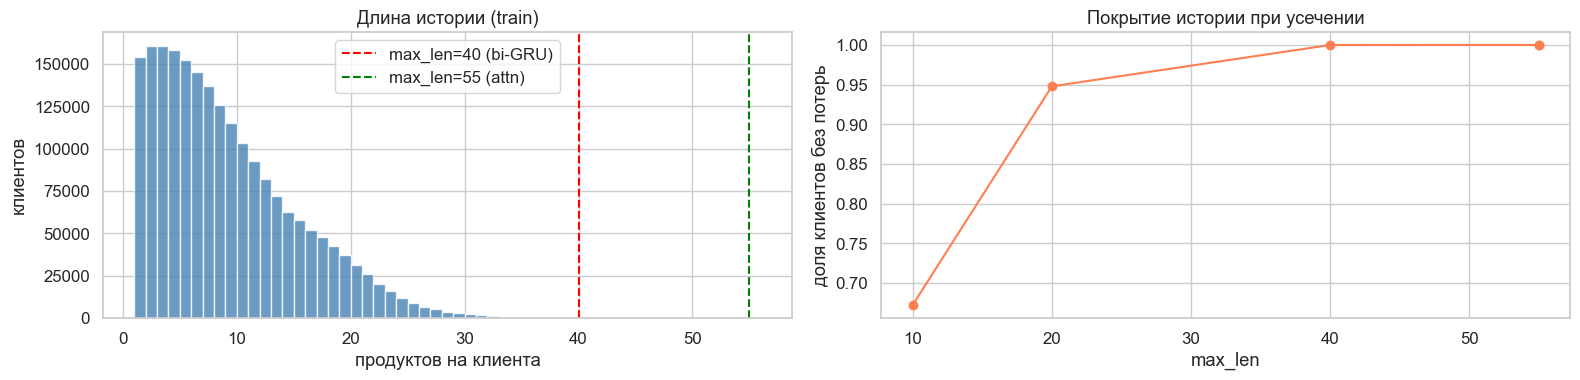

Длина train: min=1, median=7, p95=21, max=55
Длина test:  min=1, median=7, p95=21, max=58
 max_len  доля клиентов ≤ max_len
      10                 0.672310
      20                 0.947826
      40                 0.999944
      55                 1.000000
      55                 1.000000


In [14]:
len_tr = train.groupby(ID).size()
len_te = test.groupby(ID).size()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].hist(len_tr, bins=range(1, len_tr.max()+2), color="steelblue", alpha=0.8)
axes[0].set_title("Длина истории (train)"); axes[0].set_xlabel("продуктов на клиента"); axes[0].set_ylabel("клиентов")
axes[0].axvline(40, color="red", ls="--", label="max_len=40 (bi-GRU)")
axes[0].axvline(55, color="green", ls="--", label="max_len=55 (attn)")
axes[0].legend()

# доля клиентов, попадающих под усечение
cov = pd.DataFrame({
    "max_len": [10, 20, 40, 55, len_tr.max()],
})
cov["доля клиентов ≤ max_len"] = [ (len_tr <= m).mean() for m in cov["max_len"] ]
axes[1].plot(cov["max_len"], cov["доля клиентов ≤ max_len"], "o-", color="coral")
axes[1].set_title("Покрытие истории при усечении"); axes[1].set_xlabel("max_len"); axes[1].set_ylabel("доля клиентов без потерь")
plt.tight_layout(); plt.show()

print(f"Длина train: min={len_tr.min()}, median={int(len_tr.median())}, p95={int(len_tr.quantile(.95))}, max={len_tr.max()}")
print(f"Длина test:  min={len_te.min()}, median={int(len_te.median())}, p95={int(len_te.quantile(.95))}, max={len_te.max()}")
print(cov.to_string(index=False))

## 4. Признаки — категориальные коды и кардинальности

**Все 59 признаков — целочисленные коды** (бины 0–19, статусы 0–4, флаги 0/1). Это ключ к решению: каждый получает собственный эмбеддинг, а не трактуется как число.

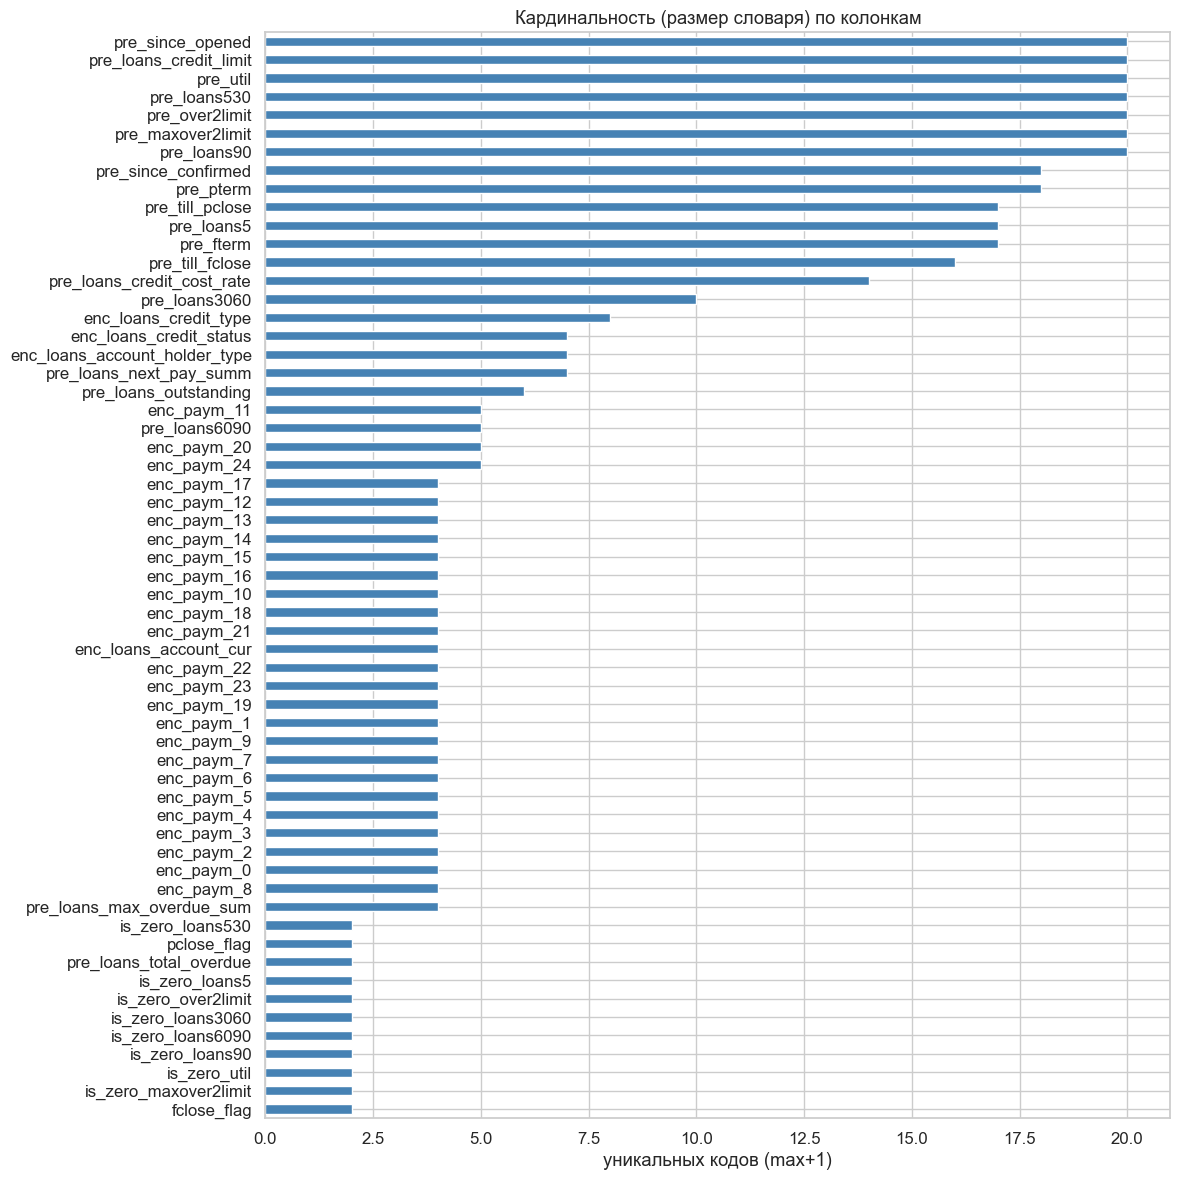

Кардинальность по группам:
  enc_paym (25)      min=4, max=5
  delinquency (5)    min=5, max=20
  is_zero_loans (5)  min=2, max=2
  categorical (4)    min=4, max=8
  flags              min=2, max=2
  ordinal (15)       min=2, max=20

Суммарный размер эмбеддинг-таблицы: 440 строк


In [15]:
groups = {
    "enc_paym (25)": C.ENC_PAYM_COLS,
    "delinquency (5)": C.DELINQ_COLS,
    "is_zero_loans (5)": C.IS_ZERO_LOANS_COLS,
    "categorical (4)": C.CATEGORICAL_COLS,
    "flags": C.FLAG_COLS,
    "ordinal (15)": C.ORDINAL_COLS,
}
card = {c: int(max(train[c].max(), test[c].max())) + 1 for c in feature_cols}
card_s = pd.Series(card).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 12))
card_s.plot.barh(ax=ax, color="steelblue")
ax.set_title("Кардинальность (размер словаря) по колонкам"); ax.set_xlabel("уникальных кодов (max+1)")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print("Кардинальность по группам:")
for name, cols in groups.items():
    vals = [card[c] for c in cols if c in card]
    if vals: print(f"  {name:18s} min={min(vals)}, max={max(vals)}")
print(f"\nСуммарный размер эмбеддинг-таблицы: {sum(card.values()):,} строк")

## 5. Одномерная предсказательная сила (id-level)\n\nКаждый признак агрегируем по клиенту (mean) и считаем ROC-AUC против `flag`. Показывает, где сигнал.

In [ ]:
# id-агрегаты (mean) — берём подвыборку клиентов для скорости
from sklearn.metrics import roc_auc_score
agg = train.groupby(ID)[feature_cols].mean()
agg = agg.loc[agg.index.isin(target.index)]
yy = target.reindex(agg.index)

uni = []
for col in feature_cols:
    m = agg[col].notna()
    if m.sum() < 100 or yy[m].nunique() < 2: continue
    a = roc_auc_score(yy[m], agg.loc[m, col])
    uni.append({"feature": col, "auc": max(a, 1-a)})
uni_df = pd.DataFrame(uni).sort_values("auc")

fig, ax = plt.subplots(figsize=(10, max(6, len(uni_df)*0.28)))
colors = ["coral" if a > 0.58 else "steelblue" for a in uni_df["auc"]]
ax.barh(uni_df["feature"], uni_df["auc"]-0.5, left=0.5, color=colors)
ax.axvline(0.5, color="gray", ls="--"); ax.set_xlabel("Univariate ROC-AUC (mean-агрегат)")
ax.set_title("Одномерная сила признаков (id-level mean)")
plt.tight_layout(); plt.show()
print("Топ-10:\n", uni_df.tail(10).iloc[::-1].to_string(index=False))

## 6. Категориальные признаки vs target\n\nЧетыре истинно-категориальных кода `enc_loans_*` — prevalence дефолта по значениям.

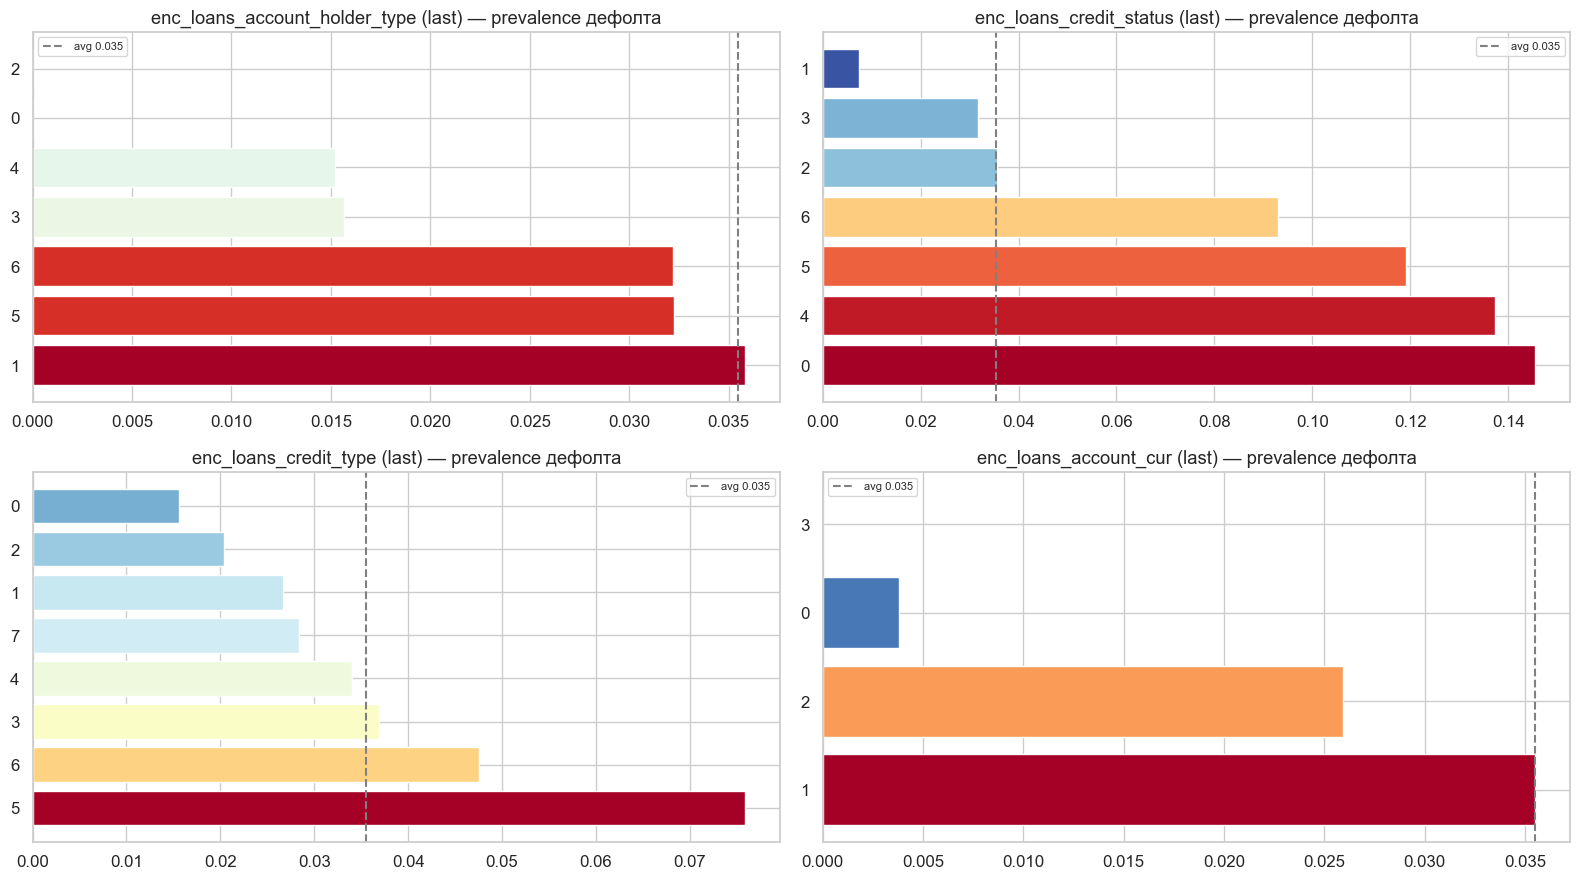

enc_loans_account_holder_type: train 7 кодов, test 7, только в test: set()
enc_loans_credit_status: train 7 кодов, test 7, только в test: set()
enc_loans_credit_type: train 8 кодов, test 8, только в test: set()
enc_loans_account_cur: train 4 кодов, test 4, только в test: set()


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, col in zip(axes.ravel(), C.CATEGORICAL_COLS):
    last = train.sort_values(RN).groupby(ID)[col].last()   # последний продукт
    df = pd.DataFrame({col: last, TGT: target.reindex(last.index)}).dropna()
    ct = df.groupby(col)[TGT].agg(["mean", "size"]).sort_values("mean", ascending=False)
    ax.barh(ct.index.astype(str), ct["mean"], color=plt.cm.RdYlBu_r(ct["mean"]/max(ct["mean"].max(),1e-9)))
    ax.axvline(prevalence, color="gray", ls="--", label=f"avg {prevalence:.3f}")
    ax.set_title(f"{col} (last) — prevalence дефолта"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for col in C.CATEGORICAL_COLS:
    tr_v, te_v = set(train[col].unique()), set(test[col].unique())
    print(f"{col}: train {len(tr_v)} кодов, test {len(te_v)}, только в test: {te_v - tr_v}")

## 7. Sentinel-коды и распределения

Часть колонок использует фиксированные коды-заглушки (напр. `pre_pterm=4` при `pclose_flag=1`). Эмбеддинги обрабатывают их нативно (отдельная строка таблицы), но полезно видеть.

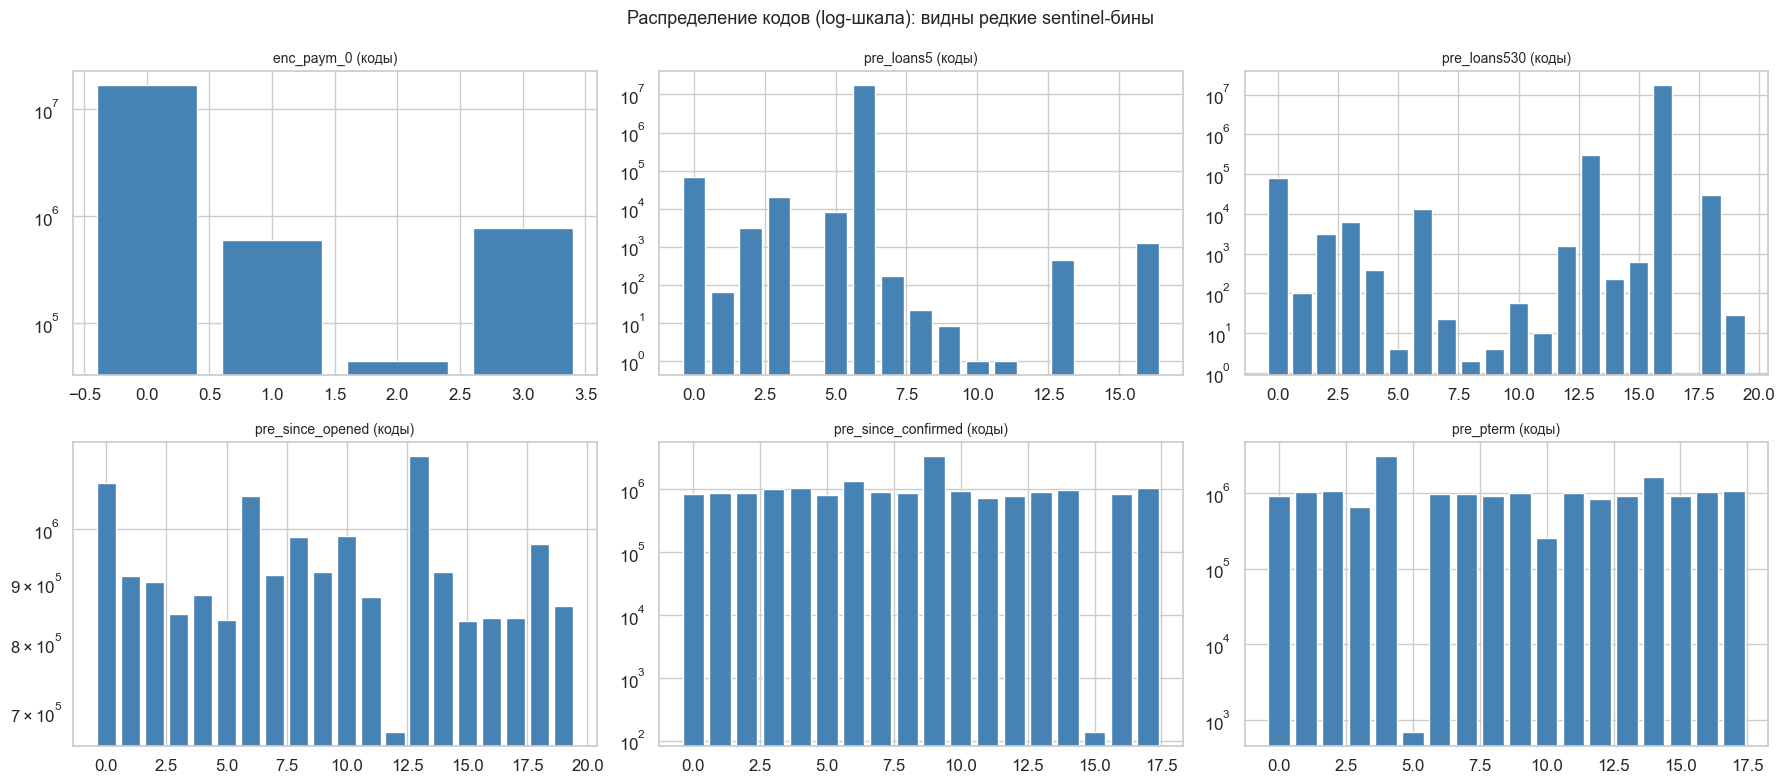

In [8]:
show = C.ENC_PAYM_COLS[:1] + C.DELINQ_COLS[:2] + C.ORDINAL_COLS[:3]
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, col in zip(axes.ravel(), show):
    vc = train[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color="steelblue")
    ax.set_title(f"{col} (коды)", fontsize=10); ax.set_yscale("log")
plt.suptitle("Распределение кодов (log-шкала): видны редкие sentinel-бины", fontsize=13)
plt.tight_layout(); plt.show()

## 8. Временная структура и train/test

`id` упорядочены по времени (поздние `id` — тест). Проверяем стабильность prevalence и длины истории между train и test.

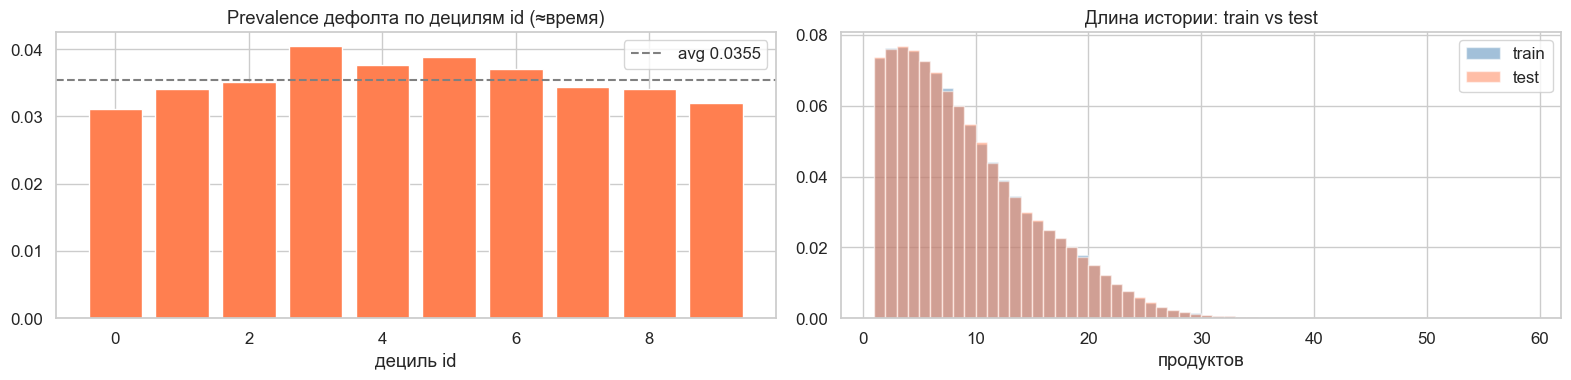

Prevalence по децилям: min=0.0311, max=0.0405


In [9]:
# prevalence по бинам id (прокси времени)
bins = pd.qcut(np.argsort(np.argsort(agg.index.values)), 10, labels=False)
prev_by_bin = pd.Series(yy.values, index=bins).groupby(level=0).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].bar(range(len(prev_by_bin)), prev_by_bin.values, color="coral")
axes[0].axhline(prevalence, color="gray", ls="--", label=f"avg {prevalence:.4f}")
axes[0].set_title("Prevalence дефолта по децилям id (≈время)"); axes[0].set_xlabel("дециль id"); axes[0].legend()

axes[1].hist(len_tr, bins=range(1, max(len_tr.max(), len_te.max())+2), density=True, alpha=0.5, color="steelblue", label="train")
axes[1].hist(len_te, bins=range(1, max(len_tr.max(), len_te.max())+2), density=True, alpha=0.5, color="coral", label="test")
axes[1].set_title("Длина истории: train vs test"); axes[1].set_xlabel("продуктов"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"Prevalence по децилям: min={prev_by_bin.min():.4f}, max={prev_by_bin.max():.4f}")

## 9. Корреляционная матрица id-агрегатов

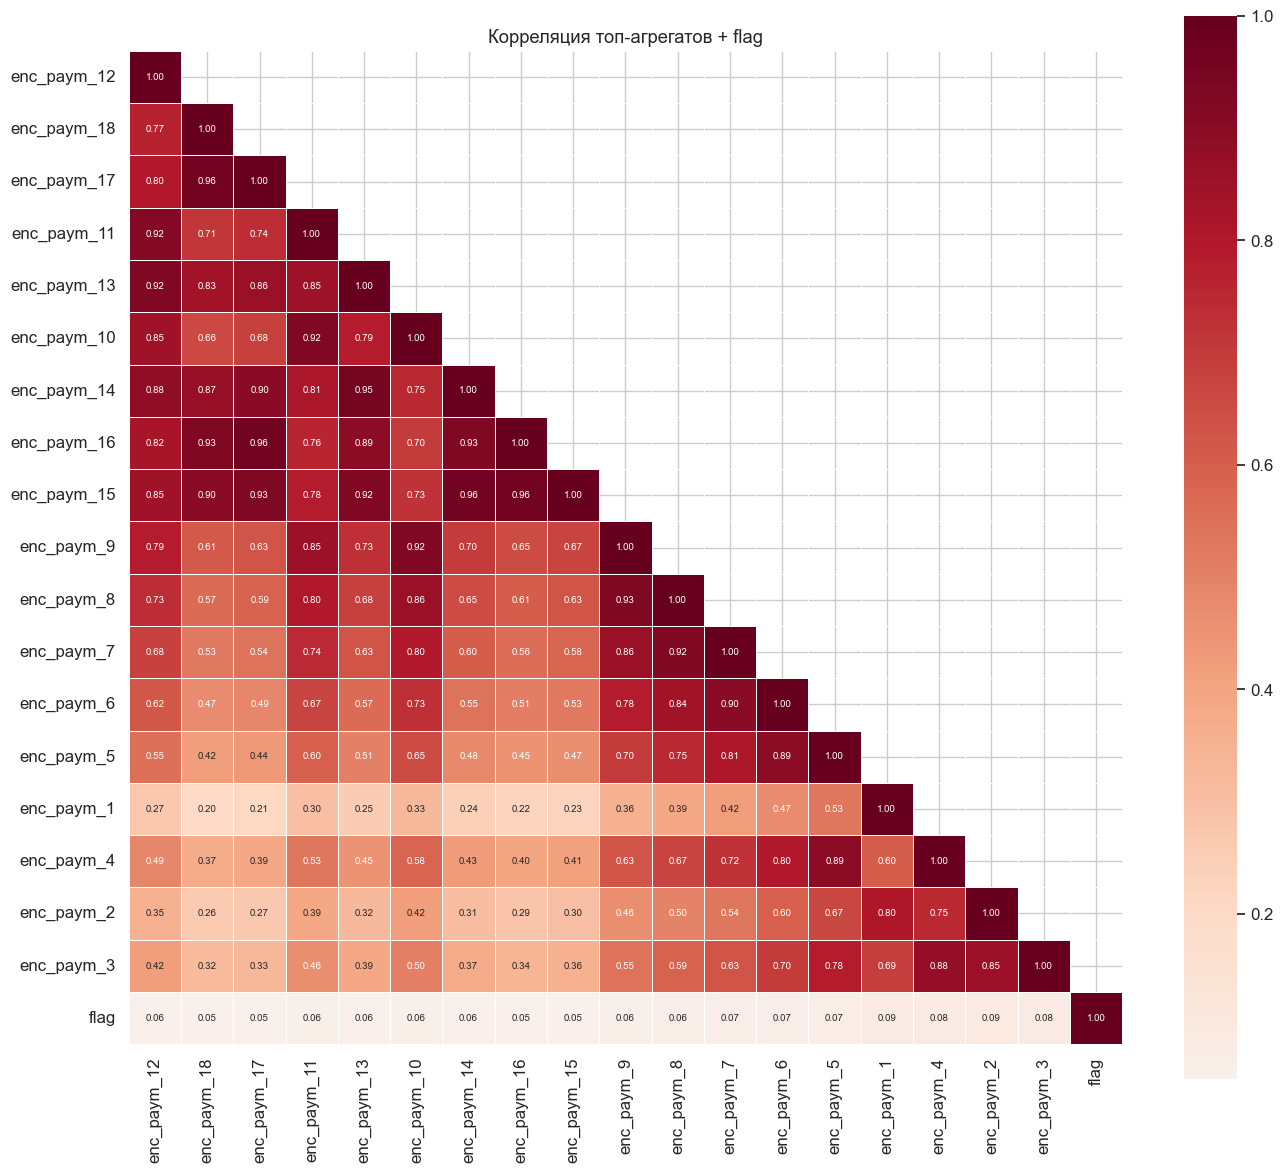

In [10]:
top = uni_df.tail(18)["feature"].tolist()
corr = agg[top].copy(); corr[TGT] = yy
cm = corr.corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
sns.heatmap(cm, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            linewidths=0.5, annot_kws={"size": 7}, ax=ax)
ax.set_title("Корреляция топ-агрегатов + flag")
plt.tight_layout(); plt.show()

## Выводы

1. **Long-формат, 2.1M клиентов, 1–55 продуктов в истории** — метка одна на клиента; сигнал в **последовательности** продуктов.
2. **Все 59 признаков — категориальные коды** → per-column эмбеддинги дают +0.025 OOF к scaled-numeric (главный рычаг).
3. **Дисбаланс 3.55%** — компенсируется `pos_weight`/`scale_pos_weight`.
4. **Длина истории:** медиана невелика, max_len=40 покрывает большинство; усечение хвоста — минимальная потеря.
5. **Временной дрейф слабый:** prevalence по децилям id стабильна, train/test близки — random-CV OOF надёжно переносится на LB (гэп ≈0).
6. **GBDT-агрегаты на плато (~0.755):** одномерная сила mean-агрегатов ограничена; порядок продуктов, который агрегаты теряют, — основной сигнал.

Подробности решения — в [SOLUTION.md](../SOLUTION.md).